# 1.1 Importing required libraries

In [1]:


# standard imports for when working with pandas and numpy
import pandas as pd
import numpy as np

# matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns



# 1.2 Read the dataset

In [2]:
# read the database
df=pd.read_csv("us_birth2.csv")


In [3]:
# display first 10 rows
df.head()

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.0,6,9083.0,01-01-2000
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000


In [22]:
# display last 10 rows
df.tail()

,year,month,date_of_month,day_of_week,births,date
5474,2014,12,27.0,6,8656.0,12/27/2014
5475,2014,12,28.0,7,7724.0,12/28/2014
5476,2014,12,29.0,1,12811.0,12/29/2014
5477,2014,12,30.0,2,13634.0,12/30/2014
5478,2014,12,NaN,3,11990.0,12/31/2014


# 1.3 Checking the data set information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5479 non-null   int64  
 1   month          5479 non-null   int64  
 2   date_of_month  5478 non-null   float64
 3   day_of_week    5479 non-null   int64  
 4   births         5465 non-null   float64
 5   date           5479 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 257.0+ KB


#There are 5478 rows and 6 columns

# 1.4 Describing the dataset

In [6]:
df.describe()

,year,month,date_of_month,day_of_week,births
count,5479.000000,5479.000000,5478.000000,5479.000000,5465.000000
mean,2006.999270,6.522723,15.727455,3.999817,11348.814456
std,4.321085,3.449075,8.799535,2.000502,2327.445105
min,2000.000000,1.000000,1.000000,1.000000,5728.000000
25%,2003.000000,4.000000,8.000000,2.000000,8739.000000
50%,2007.000000,7.000000,16.000000,4.000000,12343.000000
75%,2011.000000,10.000000,23.000000,6.000000,13083.000000
max,2014.000000,12.000000,31.000000,7.000000,16081.000000


#displays the statistical information

# 2 Data Wragling

2b) Remove Rows Corresponding to Holidays

In [7]:
holidays = ((df['month'] == 1) & (df['date_of_month'] == 1)) | \
           ((df['month'] == 7) & (df['date_of_month'] == 4)) | \
           ((df['month'] == 12) & (df['date_of_month'] == 25))

df = df[~holidays]

In [8]:
df

,year,month,date_of_month,day_of_week,births,date
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
5,2000,1,6.0,4,NaN,01-06-2000
...,...,...,...,...,...,...
5474,2014,12,27.0,6,8656.0,12/27/2014
5475,2014,12,28.0,7,7724.0,12/28/2014
5476,2014,12,29.0,1,12811.0,12/29/2014
5477,2014,12,30.0,2,13634.0,12/30/2014


# common us holidays
1. new year- jan 1
2. independence day- july 4
3. christmas- dec 25

# 2.2 Remove weekday Rows where Birth<1000

In [9]:
df=df[~((df['day_of_week']<=5)&(df['births']<10000))]

In [10]:
df

,year,month,date_of_month,day_of_week,births,date
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
5,2000,1,6.0,4,NaN,01-06-2000
...,...,...,...,...,...,...
5474,2014,12,27.0,6,8656.0,12/27/2014
5475,2014,12,28.0,7,7724.0,12/28/2014
5476,2014,12,29.0,1,12811.0,12/29/2014
5477,2014,12,30.0,2,13634.0,12/30/2014


1. day of week <=5-- selects (monday - friday)
2. (birth<10000)-- low birth count\n
3. hence the removal of abnormal data is done

# 2.3 Average Births per day of Week

In [11]:
avg_births=df.groupby('day_of_week')['births'].mean()
print(avg_births)

day_of_week
1    12145.919837
2    13191.042857
3    12967.827497
4    13009.237086
5    12708.005284
6     8571.628866
7     7523.255155
Name: births, dtype: float64


1. provides the average mean value of birth per day of week and here the numbers are represented as days of week(sun,mon...,sat)
2. Weekdays have higher births (specially tuesday and thirsday)
3. sunday has lowest births

# 2.4 Median Births per day

In [12]:
median_births=df.groupby('day_of_week')['births'].median()
print(median_births)

day_of_week
1    12141.5
2    13206.0
3    12949.0
4    12985.0
5    12667.0
6     8575.5
7     7515.5
Name: births, dtype: float64


median values of births

# 2.5 Dispersion of births (Standard Deviation)

In [13]:
dispersion = df.groupby('day_of_week')['births'].std()
print(dispersion)

day_of_week
1    628.929305
2    685.675857
3    736.101952
4    723.970982
5    750.823985
6    481.240881
7    391.597251
Name: births, dtype: float64


1. shows how spread out birth values are
2. friday has highest variation
3. sunday has lowest variation

# 2.6 Interquartile Range (IQR)

In [14]:
Q1=df.groupby('day_of_week')['births'].quantile(0.25)
Q3=df.groupby('day_of_week')['births'].quantile(0.75)

IQR = Q3-Q1
print(IQR)

day_of_week
1    863.50
2    883.25
3    936.00
4    947.00
5    947.00
6    602.00
7    516.00
Name: births, dtype: float64


# 2.7 Detect Outliers Using IQR


In [15]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df['births']<lower[df['day_of_week']].values)|(df['births']>upper[df['day_of_week']].values)]

In [16]:
print(outliers)

      year  month  date_of_month  day_of_week   births        date
190   2000      7            9.0            7   8586.0  07-09-2000
252   2000      9            9.0            6   9860.0  09-09-2000
253   2000      9           10.0            7   8552.0  09-10-2000
259   2000      9           16.0            6   9780.0   9/16/2000
260   2000      9           17.0            7   8683.0   9/17/2000
...    ...    ...            ...          ...      ...         ...
4442  2012      2           29.0            3  11042.0   2/29/2012
4687  2012     10           31.0            3  11012.0  10/31/2012
4750  2013      1            2.0            3  10887.0  01-02-2013
5052  2013     10           31.0            4  10975.0  10/31/2013
5473  2014     12           26.0            5  10386.0  12/26/2014

[75 rows x 6 columns]


In [17]:
# Lower Bound
Q1-1.5*IQR

day_of_week
1    10385.750
2    11384.375
3    11067.000
4    11084.000
5    10821.500
6     7357.000
7     6486.750
Name: births, dtype: float64

In [18]:
# Upper Bound
Q3+1.5*IQR

day_of_week
1    13839.750
2    14917.375
3    14811.000
4    14872.000
5    14609.500
6     9765.000
7     8550.750
Name: births, dtype: float64

# values outside this ranges are outliers

# 2.8 Box and Whisker Plot 

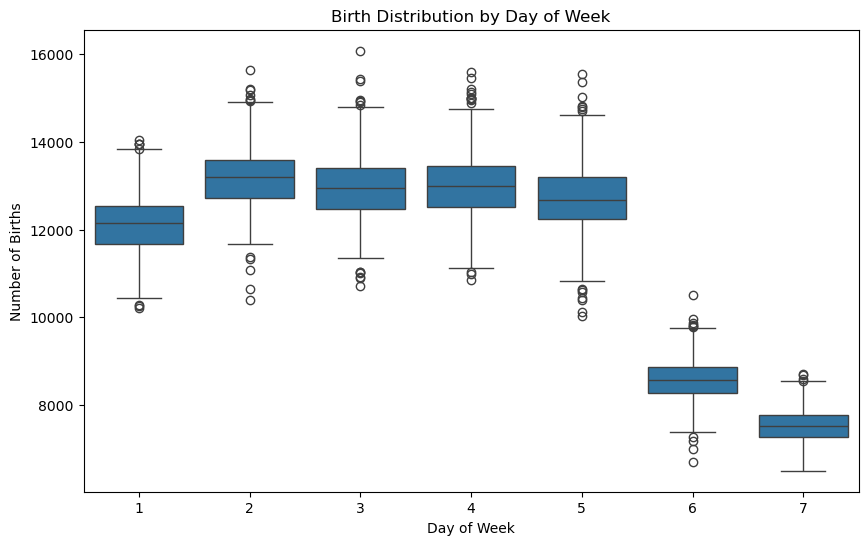

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day_of_week', y='births', data=df)

plt.title("Birth Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Births")

plt.show()

1. Box plot shows the median,quartiles and outliers
observations
1. week days have higher births
2. Weekends have lower births

# 2.9 Histogram + KDE Plot

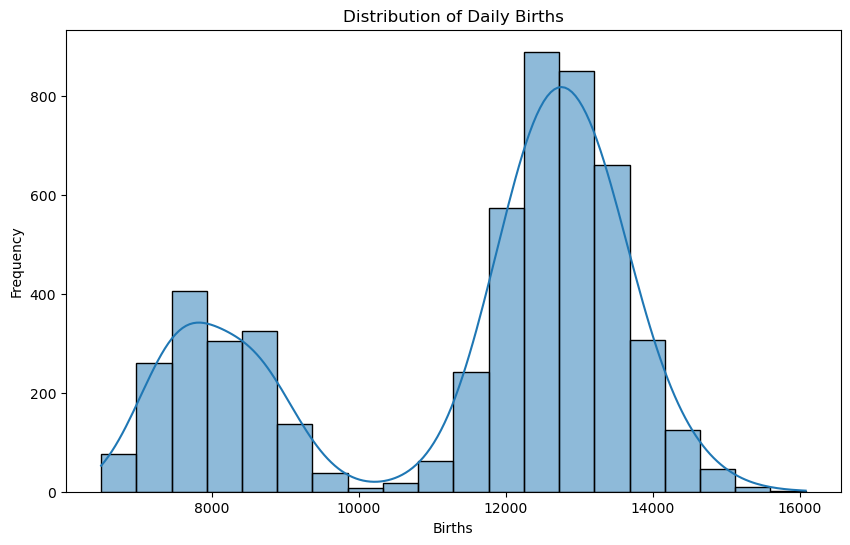

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df['births'], kde=True)

plt.title("Distribution of Daily Births")
plt.xlabel("Births")
plt.ylabel("Frequency")

plt.show()

# Birth counts are concentrated around a central range
1. Most daily birth values fall between 11,000 and 13,000 births.
2. Distribution appears approximately normal
3. The KDE curve forms a bell-shaped curve, meaning births are fairly evenly distributed around the mean.
4. Very low and very high birth counts are rare
5. Very low and very high birth counts are rare
6. At the left and right ends of the graph, the bars are shorter.

# 2.10 Day of Year Where 50% Birth Occurance

# By this Day half of Births have occured


# 2.11 In 2000 Between Which Days 50% Births Occur 


In [ ]:
data2000 = df[df['year'] == 2000]

Q1 = data2000['day_of_year'].quantile(0.25)
Q3 = data2000['day_of_year'].quantile(0.75)

print(Q1, Q3)

Half of births occured roughly APRIL--SEPTEMBER

# Summary
1. Weekdays have higher births than weekends.
2. Tuesday and Thursday show highest average births.
3. Sunday has lowest births.
4. Birth distribution is consistent with moderate variation.
5. Most births occur in the middle months of the year.